<a href="https://colab.research.google.com/github/RamadaniOktavia/ImageProcessing_2311533002/blob/main/Pertemuan%202/Tugas_Pertemuan_2_Image_Processing_2311533002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File 'image1.jpg' dan 'image2.jpg' berhasil dibuat di sistem Colab!


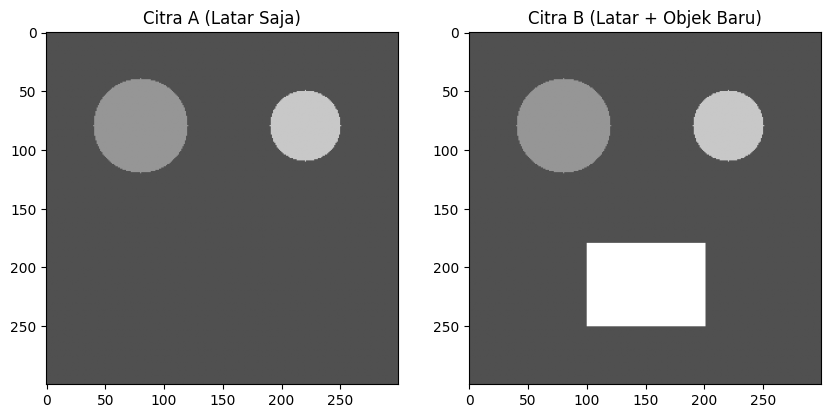

In [ ]:
# Sel 0: Skrip Pembuat Gambar Otomatis untuk Praktik
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Bikin Citra A (Latar Belakang)
# Membuat kanvas abu-abu gelap berukuran 300x300 piksel
citra_A = np.ones((300, 300), dtype=np.uint8) * 80

# Tambahkan beberapa objek statis sebagai background (misal: dua lingkaran)
cv2.circle(citra_A, (80, 80), 40, 150, -1)   # Lingkaran abu-abu terang
cv2.circle(citra_A, (220, 80), 30, 200, -1)  # Lingkaran lebih terang

# 2. Bikin Citra B (Latar Belakang + Ada Objek Baru)
citra_B = citra_A.copy()

# Tambahkan OBJEK BARU (misal: sebuah kotak putih terang di tengah bawah)
cv2.rectangle(citra_B, (100, 180), (200, 250), 255, -1)

# 3. Simpan menjadi file JPG di Google Colab
cv2.imwrite('image1.jpg', citra_A)
cv2.imwrite('image2.jpg', citra_B)

print("File 'image1.jpg' dan 'image2.jpg' berhasil dibuat di sistem Colab!")

# Menampilkan gambar yang baru saja dibuat
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Citra A (Latar Saja)")
plt.imshow(citra_A, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 2, 2)
plt.title("Citra B (Latar + Objek Baru)")
plt.imshow(citra_B, cmap='gray', vmin=0, vmax=255)
plt.show()

In [ ]:
# Sel 1: Import Library
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Library berhasil di-import!")

Library berhasil di-import!


In [ ]:
# Sel 2: Fungsi Pengurangan Citra
def operasi_pengurangan(citra_A, citra_B):
    # Pastikan ukuran citra A dan B sama persis (M x N)
    baris, kolom = citra_A.shape

    # Buat matriks citra_C (hasil) yang diisi angka 0
    citra_C = np.zeros((baris, kolom), dtype=np.uint8)

    # Iterasi untuk setiap baris dan kolom
    for i in range(baris):
        for j in range(kolom):
            # Lakukan pengurangan. Konversi ke int agar tidak terjadi underflow pada tipe data uint8
            # Rumus: C[i][j] = A[i][j] - B[i][j]
            selisih = int(citra_A[i, j]) - int(citra_B[i, j])

            # Nilai mutlak (absolute) digunakan karena kita hanya ingin melihat perbedaannya
            selisih = abs(selisih)

            # Sesuai algoritma: Jika C[i][j] != 0 maka C[i][j] = 255 (nyatakan objek berwarna putih)
            # Catatan Praktik: Pada foto asli dari kamera HP, selalu ada "noise" cahaya.
            # Jadi kita gunakan nilai toleransi (misal 50) sebagai pengganti "!= 0" agar noise tidak ikut jadi putih.
            if selisih > 50:
                citra_C[i, j] = 255
            else:
                citra_C[i, j] = 0

    return citra_C

print("Fungsi pengurangan berhasil dibuat!")

Fungsi pengurangan berhasil dibuat!


In [ ]:
# Sel 3: Membaca Citra
# Ganti nama file di bawah ini sesuai dengan nama file yang kamu upload di langkah persiapan!
file_citra_A = 'image1.jpg'
file_citra_B = 'image2.jpg'

# Baca gambar dan ubah langsung menjadi grayscale (hitam putih)
citra_A = cv2.imread(file_citra_A, cv2.IMREAD_GRAYSCALE)
citra_B = cv2.imread(file_citra_B, cv2.IMREAD_GRAYSCALE)

# Pengecekan apakah gambar berhasil dibaca
if citra_A is None or citra_B is None:
    print("Error: Gambar tidak ditemukan! Pastikan nama file dan huruf besar/kecilnya sama persis dengan yang di-upload.")
else:
    # Samakan ukuran Citra B dengan ukuran Citra A agar bisa dikurangkan
    # Mengambil dimensi M x N dari citra A
    dimensi_A = (citra_A.shape[1], citra_A.shape[0])
    citra_B_resized = cv2.resize(citra_B, dimensi_A)

    print(f"Citra A berhasil dimuat dengan ukuran: {citra_A.shape}")
    print(f"Citra B berhasil dimuat dan di-resize menjadi: {citra_B_resized.shape}")

Citra A berhasil dimuat dengan ukuran: (300, 300)
Citra B berhasil dimuat dan di-resize menjadi: (300, 300)


Sedang memproses pengurangan citra, mohon tunggu sebentar...


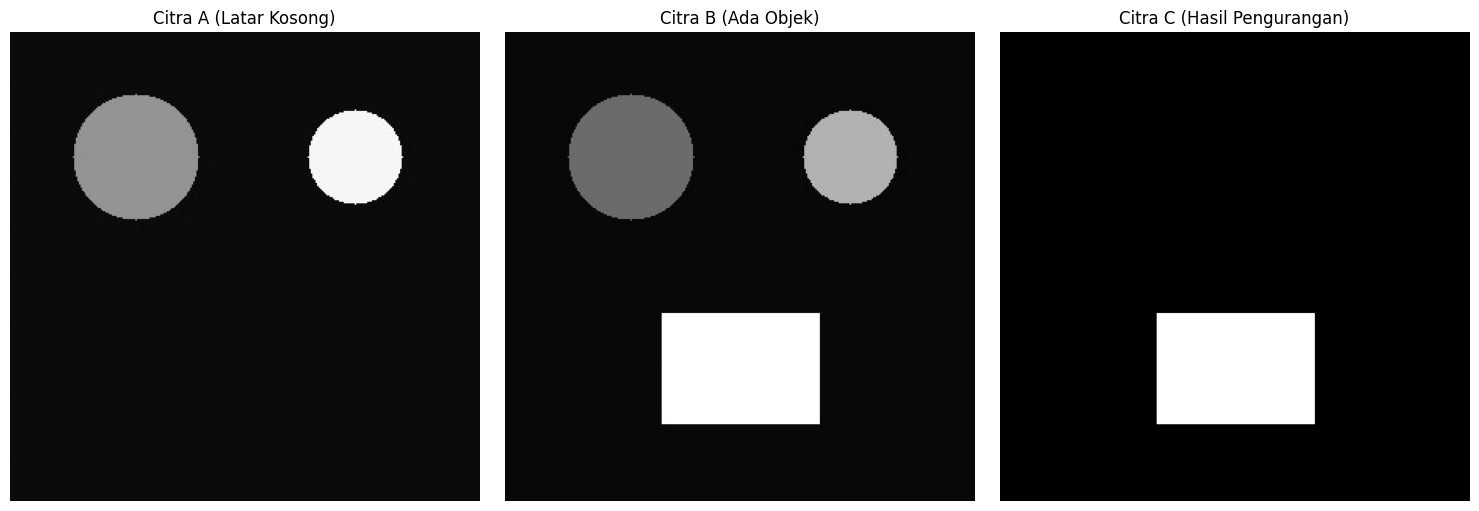

In [ ]:
# Sel 4: Eksekusi dan Visualisasi
if citra_A is not None and citra_B is not None:
    print("Sedang memproses pengurangan citra, mohon tunggu sebentar...")

    # Jalankan fungsi pengurangan
    citra_hasil = operasi_pengurangan(citra_B_resized, citra_A)

    # Tampilkan hasilnya menggunakan matplotlib
    plt.figure(figsize=(15, 5))

    # Menampilkan Citra A
    plt.subplot(1, 3, 1)
    plt.title('Citra A (Latar Kosong)')
    plt.imshow(citra_A, cmap='gray')
    plt.axis('off') # Menghilangkan sumbu x dan y

    # Menampilkan Citra B
    plt.subplot(1, 3, 2)
    plt.title('Citra B (Ada Objek)')
    plt.imshow(citra_B_resized, cmap='gray')
    plt.axis('off')

    # Menampilkan Citra Hasil (C)
    plt.subplot(1, 3, 3)
    plt.title('Citra C (Hasil Pengurangan)')
    plt.imshow(citra_hasil, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()